# Анализ данных заведений общественного питания города Москвы.

- Автор: Севрюкова В.Ю.
- Дата: 25.01.2026г.

### Цели и задачи проекта

**Цель:** Провести исследовательский анализ данных заведений общественного питания г. Москвы с выявлением места для построения бизнеса в общепите инвесторами.

### Описание данных

Для анализа поступили данные о заведениях общественного питания г. Москвы. Данные состоят из двух датасетов:

- `/datasets/rest_info.csv` — содержит информацию о заведениях общественного питания;
- `/datasets/rest_price.csv` — содержит информацию о среднем чеке в заведениях общественного питания.

 Описание датасета `/datasets/rest_info.csv`:
 
 
* name — название заведения;
* address — адрес заведения;
* district — административный район, в котором находится заведение, например Центральный административный округ;
* category — категория заведения, например «кафе», «пиццерия» или «кофейня»;
* hours — информация о днях и часах работы;
* rating — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
* chain — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
  0 — заведение не является сетевым;
  1 — заведение является сетевым.
* seats — количество посадочных мест.

Описание датасета `/datasets/rest_price.csv`:
* price — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
* avg_bill — хранит среднюю стоимость заказа в виде диапазона, например:
  «Средний счёт: 1000–1500 ₽»;
  «Цена чашки капучино: 130–220 ₽»;
  «Цена бокала пива: 400–600 ₽».
  и так далее;
* middle_avg_bill — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
  Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
  Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
  Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
* middle_coffee_cup — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
  Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
  Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
  Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.
 










### Содержимое проекта


1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.



## 1. Загрузка данных и знакомство с ними


In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

!pip install phik

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix as ph

In [2]:
# Выгружаем данные в переменные rest_info и rest_price
rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

In [3]:
# Выводим первые строки датафрейма rest_info на экран
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Выводим информацию о датафрейме rest_info 
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [5]:
# Выводим первые строки датафрейма rest_price на экран
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
# Выводим информацию о датафрейме
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


---

### Промежуточный вывод



Датасет /datasets/rest_info.csv/ содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания г.Москвы.

После первичного анализа данных можно сделать следующие выводы:

Названия столбцов лучше привести к одному виду, например snake case. Все представленные данные содержат числовые значения и текстовые, хранятся в типах данных int64,float64, object . Значения в столбцах chain, rating, seats - представлены целыми числами. chain показывает наличие у клиента того или иного признака и содержит значения 1 или 0 — размерность этих данных можно оптимизировать. Тип данных hours и seats не соответствуют логическому типу данных, следует поменять на соответствующий. Пропуски содержатся только в столбцах hours и seats. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных. Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Датасет /datasets/rest_price.csv содержит 5 столбцов и 4058 строк, в которых представлена информация о среднем чеке в заведениях общественного питания г.Москвы.

После первичного анализа данных можно сделать следующие выводы:

Названия столбцов лучше привести к одному виду, например snake case. Все представленные данные содержат числовые значения и текстовые, хранятся в типах данных float64 и object. Значения в столбцах  middle_avg_bill и middle_coffee_cup - представлены вещественными числами. Пропуски содержатся только в столбцах price,avg_bill,middle_avg_bill,middle_coffee_cup. Тип данных в столбцах id и price кажутся не соответствующим.Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

### Подготовка единого датафрейма

In [7]:
# Соединяем данные в единый датафрейм df
df = pd.merge(rest_info, rest_price, on='id',how='left')

In [8]:
print("Процент потерянных данных при объединении таблиц:",round((len(rest_info)-len(df))/len(rest_info)*100,2), "%")

Процент потерянных данных при объединении таблиц: 0.0 %


In [9]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [10]:
# Выводим первые строки датафрейма 
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [11]:
# Создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
temp = df.copy() 
len(temp)

8406

## 2. Предобработка данных

In [12]:
# Проверим типы данных в датафрейме df с помощью атрибута dtypes
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  int64
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

In [13]:
# Переведем seats и chain в целочисленный тип данных в датафрейме df
df[['seats','chain']] = df[['seats','chain']].astype('Int64')

In [14]:
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  Int64
seats                  Int64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

<font color='DarkMagenta'>👉 Можно еще понизить разрядность числовых данных с 64 до 32, примерно вот так:<br>
`for column in ['rating','middle_avg_bill','middle_coffee_cup']:`<br>
&nbsp;&nbsp;&nbsp;&nbsp;`df[column] = pd.to_numeric(df[column], downcast='float')`</font>

In [15]:
# Применяем метод isna() к датафрейму df
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [16]:
# Подсчитываем долю строк с пропусками
df.isna().sum()/df.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

In [17]:
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
hours,536,0.0638
seats,3611,0.4296
price,5091,0.6056
avg_bill,4590,0.5460
middle_avg_bill,5257,0.6254
middle_coffee_cup,7871,0.9364


В датафрейме df обнаружено 536 пропусков в столбце hours — это 6% данных, в столбце seats 3611 пропусков, это 43 %, в столбце price 5091 (61%), в стобце avg_bill 4590 (55%), в стобце middle_avg_bill 5257 (63 %) в стобце middle_coffee_cup 7871 (94 %).

Пропуски в этих столбцах могут быть вызваны:
*  Недостаточность данных: в некоторых случаях данные просто не были собраны или недоступны. 
*  Ошибки при вводе данных: человеческий фактор может привести к тому, что данные будут пропущены или некорректно введены.
*  Проблемы с форматом данных: при объединении или преобразовании данных из разных источников могут возникнуть несовпадения форматов, что приведёт к появлению пропусков.
*  Логические пропуски: в некоторых случаях пропуски могут быть логическим следствием структуры данных. 
*  Технические проблемы: ошибки при экспорте или импорте данных, сбои в системах хранения данных также могут привести к появлению пропусков.   

In [18]:
# Определяем функцию, которая создаст новый столбец с бинарным признаком в зависимости от наличия данных в другом столбце
def create_is_na(x):
    """
    Функция создаёт новый столбец с бинарным признаком, который указывает
    на наличие данных в столбце. Функция применяется к столбцу после метода isna()
    """
    if x:
        return 0
    return 1


Функция применяется к столбцу, в котором следует проверить данные, после метода isna(). Этот метод проверяет пропуски в данных и, если пропуск есть, возвращает True. В случае True срабатывает условие if x — функция возвращает 0, что означает, что в столбце нет данных. Если пропуска нет, метод isna() вернёт False. Тогда условие if x не сработает, и код вернёт 1. Применим эту функцию к столбцу hours и создадим новый столбец is_hours:

In [19]:
# Создаём столбец is_seats с помощью функции create_is_na
df['is_seats'] = df['seats'].isna().apply(create_is_na)

In [20]:
# Проводим агрегацию данных по полю is_hours
df.groupby('is_seats').agg({
    'rating':'median',
    'chain':'mean'    
})

,rating,chain
is_seats,,
0,4.3,0.353919
1,4.3,0.401877


Можно сделать такие выводы о связи между пропусками в столбце seats(количество посадочных мест) и другими показателями:

Количество посадочных мест не влияет на рейтинг заведения, и взаимосвязи с типом заявления практически не наблюдается.

In [21]:
# Комментарий ревьюера
# Проверим сколько удалено строк датасета
a, b = len(temp), len(df)
print(a, b, round((a-b)/a*100, 2))

8406 8406 0.0


In [22]:
# Проверяем 
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
is_seats                0
dtype: int64

In [23]:
# Проверяем уникальные значения
unique_values_column1 = df['rating'].unique()
unique_values_column2 = df['seats'].unique()

In [24]:
print("Уникальные значения в столбце 'rating':", unique_values_column1)
print("Уникальные значения в столбце 'seats':", unique_values_column2)

Уникальные значения в столбце 'rating': [5.  4.5 4.6 4.4 4.7 4.8 4.3 4.9 4.2 4.1 4.  3.8 3.9 3.7 3.6 2.8 2.7 3.1
 1.5 2.  1.4 3.3 3.5 3.2 2.9 3.  3.4 2.3 2.2 2.5 2.6 1.7 1.  1.1 2.4 1.3
 1.2 2.1 1.8 1.9 1.6]
Уникальные значения в столбце 'seats': <IntegerArray>
[<NA>,    4,   45,  148,   79,   65,  102,  180,   96,   25,
 ...
  428,   13,  268,  208,  114,   33,  675,  206,  173,  305]
Length: 230, dtype: Int64


In [25]:
# Проверяем полные дубликаты 
df.duplicated().sum()

0

In [26]:
# Проверяем неявные дубликаты в датафрейме 
df.duplicated(subset='id').sum()

0

Неявных дубликатов тоже нет.

Каждая строка соответствует уникальному клиенту. Теперь проверим корректность написания категориальных значений в данных датафреймов.

In [27]:
# Проверяем уникальные значения в категориальных столбцах 
for column in ['category', 'price', 'avg_bill']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце category:
['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']

Уникальные значения в столбце price:
['высокие' 'выше среднего' 'низкие' 'средние' nan]

Уникальные значения в столбце avg_bill:
['Средний счёт:100 ₽' 'Средний счёт:1000 ₽' 'Средний счёт:1000–10000 ₽'
 'Средний счёт:1000–1100 ₽' 'Средний счёт:1000–1200 ₽'
 'Средний счёт:1000–1300 ₽' 'Средний счёт:1000–1350 ₽'
 'Средний счёт:1000–1400 ₽' 'Средний счёт:1000–1500 ₽'
 'Средний счёт:1000–1600 ₽' 'Средний счёт:1000–1700 ₽'
 'Средний счёт:1000–2000 ₽' 'Средний счёт:1000–2500 ₽'
 'Средний счёт:1000–3000 ₽' 'Средний счёт:1000–5000 ₽'
 'Средний счёт:100–1000 ₽' 'Средний счёт:100–160 ₽'
 'Средний счёт:100–180 ₽' 'Средний счёт:100–200 ₽'
 'Средний счёт:100–2000 ₽' 'Средний счёт:100–270 ₽'
 'Средний счёт:100–300 ₽' 'Средний счёт:100–330 ₽'
 'Средний счёт:100–350 ₽' 'Средний счёт:100–400 ₽'
 'Средний счёт:100–423 ₽' 'Средний счёт:100–500 ₽'
 'Средний счёт:100–599 ₽' 'С

In [28]:
# Выводим названия столбцов датафрейма 
df.columns

Index(['id', 'name', 'category', 'address', 'district', 'hours', 'rating',
       'chain', 'seats', 'price', 'avg_bill', 'middle_avg_bill',
       'middle_coffee_cup', 'is_seats'],
      dtype='object')

Все названия оформлены корректно.

In [29]:
# Нормализация данных
df['name'] = df['name'].astype(str).str.lower().str.strip().str.replace(' ', '_')
df['address'] = df['address'].astype(str).str.lower().str.strip().str.replace(' ', '_')

In [30]:
df['name']

0                     wowфли
1             четыре_комнаты
2                      хазри
3       dormouse_coffee_shop
4                  иль_марко
                ...         
8401              суши_мания
8402               миславнес
8403                 самовар
8404            чайхана_sabr
8405              kebab_time
Name: name, Length: 8406, dtype: object

In [31]:
df['address']

0                       москва,_улица_дыбенко,_7/1
1               москва,_улица_дыбенко,_36,_корп._1
2                   москва,_клязьминская_улица,_15
3              москва,_улица_маршала_федоренко,_12
4                  москва,_правобережная_улица,_1б
                           ...                    
8401                 москва,_профсоюзная_улица,_56
8402    москва,_пролетарский_проспект,_19,_корп._1
8403        москва,_люблинская_улица,_112а,_стр._1
8404        москва,_люблинская_улица,_112а,_стр._1
8405                москва,_россошанский_проезд,_6
Name: address, Length: 8406, dtype: object

In [32]:
#Проверим количество неявныех дубликатов по названию и адресу
df.duplicated(subset=['name', 'address']).sum()

4

In [33]:
#Удаляем неявные дубликаты
df = df.drop_duplicates(subset=['name', 'address'])

In [34]:
#Проверим количество неявныех дубликатов по названию и адресу
df.duplicated(subset=['name', 'address']).sum()

0

- Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [35]:
# Комментарий ревьюера
# Проверим сколько удалено строк датасета
a, b = len(temp), len(df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8402 
 Удалено строк в датасете после обработки 4 
 Процент потерь 0.05


In [36]:
# приводим столбец hours к нижнему регистру для корректной проверки
df['hours_normalized'] = df['hours'].str.lower()

# создаём признак круглосуточной работы
df['is_24_7'] = df['hours_normalized'].str.contains(    
    'ежедневно, круглосуточно',
     na=False  # для NaN возвращаем False
)              # метод contains() проверяет, содержится ли в каждой строке указанного столбца заданный текст
df['is_24_7'].value_counts()

False    7672
True      730
Name: is_24_7, dtype: int64

In [37]:
# Выводим на экран
df.loc[df['is_24_7']].head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_seats,hours_normalized,is_24_7
10,ac32978af97641bfacf996e7f5a50ee5,great_room_bar,"бар,паб","москва,_левобережная_улица,_12",Северный административный округ,"ежедневно, круглосуточно",4.5,0,102,средние,Цена бокала пива:250–350 ₽,NaN,NaN,1,"ежедневно, круглосуточно",True
17,b55465d0869648a295ad1d85ed9b5c4f,чайхана_беш-бармак,ресторан,"москва,_ленинградское_шоссе,_71б,_стр._2",Северный административный округ,"ежедневно, круглосуточно",4.4,0,96,средние,Средний счёт:350–500 ₽,425.0,NaN,1,"ежедневно, круглосуточно",True
19,feec6bedccae44cb877d99c13f9aa5d7,пекарня,булочная,"москва,_ижорский_проезд,_5",Северный административный округ,"ежедневно, круглосуточно",4.4,1,<NA>,NaN,NaN,NaN,NaN,0,"ежедневно, круглосуточно",True
24,0f5d22f5377340d0a81a9328e6ebdcac,drive_café,кафе,"москва,_улица_дыбенко,_9ас1",Северный административный округ,"ежедневно, круглосуточно",4.0,1,<NA>,NaN,NaN,NaN,NaN,0,"ежедневно, круглосуточно",True
49,a8bbd74669074068ab44bc567022ee27,2u-ту-ю,пиццерия,"москва,_ижорская_улица,_8а",Северный административный округ,"ежедневно, круглосуточно",2.7,0,<NA>,NaN,Средний счёт:900 ₽,900.0,NaN,0,"ежедневно, круглосуточно",True


---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

В результате предобработки данных были выполнены следующие действия:

Изучены пропуски в данных. В датафрейме df обнаружено 536 пропусков в столбце hours — это 6% данных, в столбце seats 3611 пропусков, это 43 %, в столбце price 5091 (61%), в стобце avg_bill 4590 (55%), в стобце middle_avg_bill 5257 (63 %) в стобце middle_coffee_cup 7871 (94 %). Так же произвели нормализацию данных в столбцах name и adres.
Данные проверили на явные и неявные дубликаты и удалены.

## 3. Исследовательский анализ данных

---

### Задача 1

Исследуем количество объектов общественного питания по каждой категории. Результат сопроводим подходящей визуализацией.

In [38]:
# Проверяем распределение данных по значениям в столбце category
for column in ['category']:
    print(f'Распределение данных по значениям столбца {column}:')
    print(df[column].value_counts(normalize=True))
    print()

Распределение данных по значениям столбца category:
кафе               0.282790
ресторан           0.243037
кофейня            0.168174
бар,паб            0.090931
пиццерия           0.075339
быстрое питание    0.071769
столовая           0.037491
булочная           0.030469
Name: category, dtype: float64



In [39]:
# Проверяем распределение данных по значениям в столбце category
for column in ['category']:
    print(f'Распределение данных по значениям столбца {column}:')
    print(df[column].value_counts())
    print()

Распределение данных по значениям столбца category:
кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64



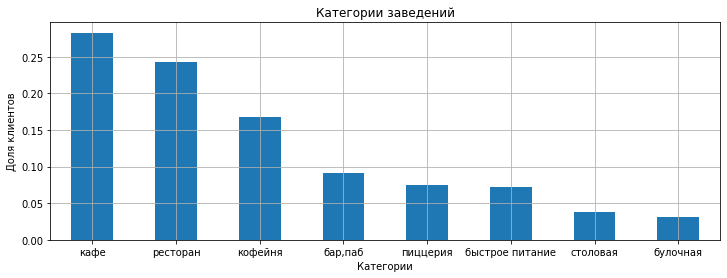

In [40]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 4))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['category'].value_counts(normalize=True).plot(
               kind='bar', # Тип графика — столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Категории заведений'
)

# Настраиваем оформление графика
plt.xlabel('Категории')
plt.ylabel('Доля клиентов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Наибольшая доля в столбце category занимаю: кафе  2327 (25,5 %), рестораны 2043 (25 %) и кофейни 1413 (18%). Наименьшую занимают столовые 315 и булочные 256 (4% и 3%).

---

### Задача 2

Исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводим подходящими визуализациями.

In [41]:
# Проверяем распределение данных по значениям в столбце
for column in ['district']:
    print(f'Распределение данных по значениям столбца {column}:')
    print(df[column].value_counts(normalize=True))
    print()

Распределение данных по значениям столбца district:
Центральный административный округ         0.266841
Северный административный округ            0.106879
Южный административный округ               0.106165
Северо-Восточный административный округ    0.105927
Западный административный округ            0.101166
Восточный административный округ           0.094977
Юго-Восточный административный округ       0.084980
Юго-Западный административный округ        0.084385
Северо-Западный административный округ     0.048679
Name: district, dtype: float64



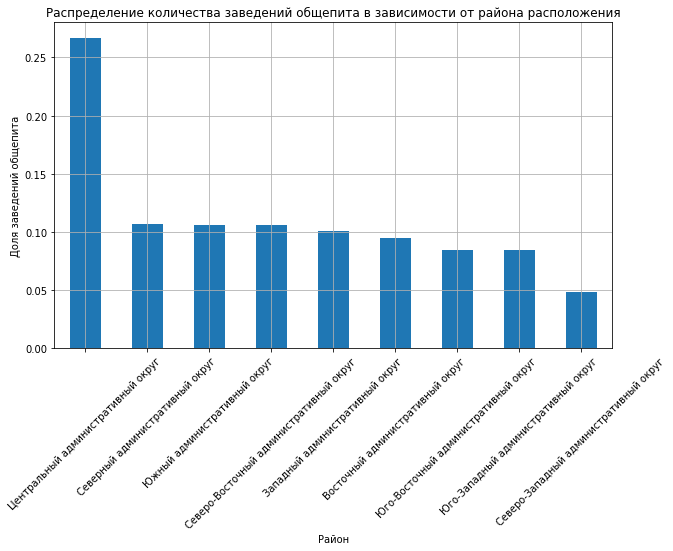

In [42]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['district'].value_counts(normalize=True).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение количества заведений общепита в зависимости от района расположения'
)

# Настраиваем оформление графика
plt.xlabel('Район')
plt.ylabel('Доля заведений общепита')
plt.xticks(rotation=45)
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

In [43]:
# Проверяем распределение данных по значениям в столбце
for column in ['district']:
    print(f'Распределение данных по значениям столбца {column}:')
    print(df[column].value_counts(normalize=True))
    print()

Распределение данных по значениям столбца district:
Центральный административный округ         0.266841
Северный административный округ            0.106879
Южный административный округ               0.106165
Северо-Восточный административный округ    0.105927
Западный административный округ            0.101166
Восточный административный округ           0.094977
Юго-Восточный административный округ       0.084980
Юго-Западный административный округ        0.084385
Северо-Западный административный округ     0.048679
Name: district, dtype: float64



In [44]:
# Проверяем распределение данных по значениям в столбце
for column in ['district']:
    print(f'Распределение данных по значениям столбца {column}:')
    print(df[column].value_counts())
    print()

Распределение данных по значениям столбца district:
Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64



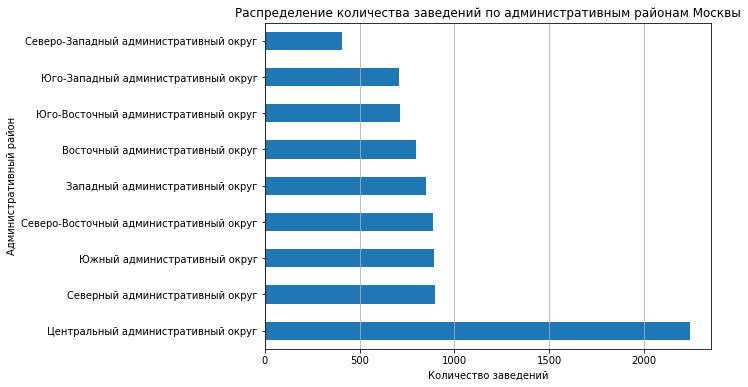

In [45]:
# Группируем данные по административным районам
district_counts = df['district'].value_counts()

# Строим горизонтальную столбчатую диаграмму
plt.figure(figsize=(8, 6))
district_counts.plot(kind='barh')
plt.xlabel('Количество заведений')
plt.ylabel('Административный район')
plt.title('Распределение количества заведений по административным районам Москвы')
plt.grid(axis='x')
plt.show()

Наибольшее количество заведений общепита находятся в Центральном административном округе 2242 (28 %), Северном административном округе 900 (11%) и Южном административном округе 891 (10%). Напротив,наименьшее количество наблюдается в Юго-Восточном административном округе 714 (8 %), Северо-Западном административном округе 409 (5 %).

In [46]:
# Фильтруем данные для Центрального административного округа
cao_df = df[df['district'] == 'Центральный административный округ']

# Группируем данные по категориям заведений в ЦАО
category_counts = cao_df['category'].value_counts()

print("Распределение заведений по категориям в Центральном административном округе:")
print(category_counts)

Распределение заведений по категориям в Центральном административном округе:
ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64


In [47]:
# Фильтруем данные для Центрального административного округа
cao_df = df[df['district'] == 'Центральный административный округ']

# Группируем данные по категориям заведений в ЦАО
category_counts = cao_df['category'].value_counts(normalize=True)

print("Распределение заведений по категориям в Центральном административном округе:")
print(category_counts)


Распределение заведений по категориям в Центральном административном округе:
ресторан           0.298840
кафе               0.206958
кофейня            0.190901
бар,паб            0.162355
пиццерия           0.050401
быстрое питание    0.038805
столовая           0.029438
булочная           0.022302
Name: category, dtype: float64


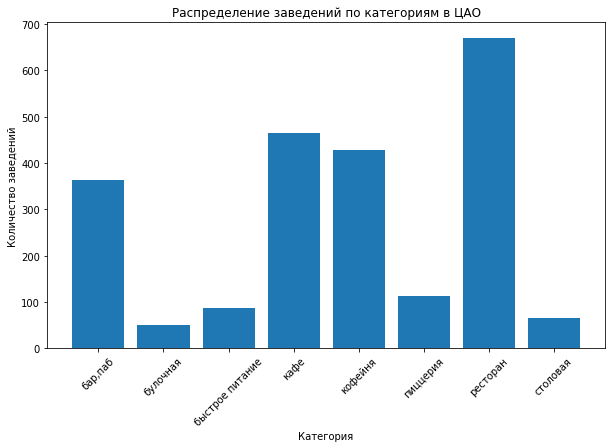

In [48]:
# Фильтрация заведений в ЦАО
cao_restaurants = df[df['district'] == 'Центральный административный округ']

# Группировка заведений по категориям
restaurants_by_category = cao_restaurants.groupby('category').size().reset_index(name='count')

# Визуализация распределения заведений по категориям
plt.figure(figsize=(10, 6))
plt.bar(restaurants_by_category['category'], restaurants_by_category['count'])
plt.title('Распределение заведений по категориям в ЦАО')
plt.xlabel('Категория')
plt.ylabel('Количество заведений')
plt.xticks(rotation=45)
plt.show()

В центральном административном округе наибольшей популярностью пользуются рестораны 670 (30%), кафе 464 (21 %), кофейни 428 (19%).Булочные 50 (2%) и столовые 66 (3%) наименее восстребованы. В топе те же группы общепита, что и в статистике по всем районам. 

---

### Задача 3

Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения.

In [49]:
# Подсчитываем общее количество сетевых и несетевых заведений
total_count = df['chain'].value_counts()
print("Общее количество сетевых и несетевых заведений:")
print(total_count)

Общее количество сетевых и несетевых заведений:
0    5199
1    3203
Name: chain, dtype: Int64


In [50]:
# Подсчитываем долю сетевых и несетевых заведений
total_count = df['chain'].value_counts(normalize=True)
print("Доля сетевых и несетевых заведений:")
print(total_count)

Доля сетевых и несетевых заведений:
0    0.618781
1    0.381219
Name: chain, dtype: Float64


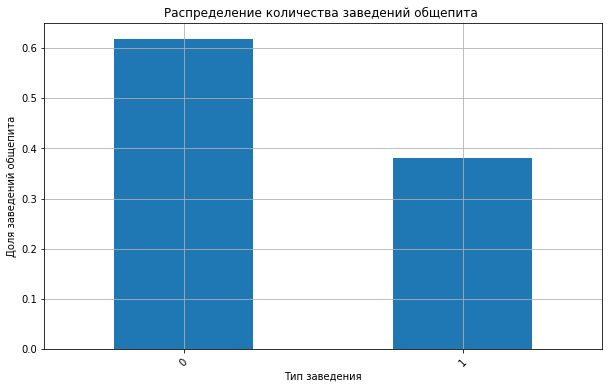

In [51]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['chain'].value_counts(normalize=True).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение количества заведений общепита '
)

# Настраиваем оформление графика
plt.xlabel('Тип заведения')
plt.ylabel('Доля заведений общепита')
plt.xticks(rotation=45)
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Доля несетевых (57 %) превышает долю сетевых (43%) заведений общепита.

In [52]:
# Группируем заведения по категориям и подсчитываем долю сетевых заведений
category_chain_count = df.groupby('category')['chain'].mean().sort_values(ascending=False)

print("Доля сетевых заведений по категориям:")
print(category_chain_count)


Доля сетевых заведений по категориям:
category
булочная           0.613281
пиццерия           0.521327
кофейня            0.509554
быстрое питание    0.384743
ресторан           0.357003
кафе               0.327862
столовая           0.279365
бар,паб            0.219895
Name: chain, dtype: Float64


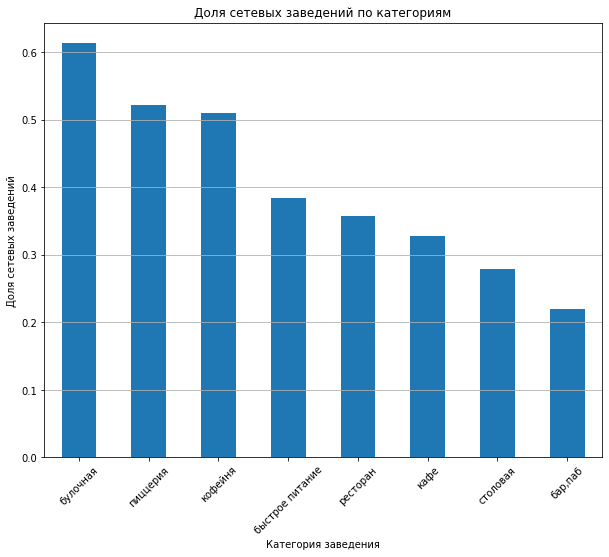

In [53]:
# Группируем заведения по категориям и подсчитываем долю сетевых заведений
category_chain_count = df.groupby('category')['chain'].mean().sort_values(ascending=False)

# Строим диаграмму
plt.figure(figsize=(10, 8))
category_chain_count.plot(kind='bar', title='Доля сетевых заведений по категориям')
plt.xlabel('Категория заведения')
plt.ylabel('Доля сетевых заведений')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

Наибольшая доля сетевых заведений приходится на булочные (65%), пиццерии (54%) и кофейни (53%). 

---

### Задача 4

Исследуем количество посадочных мест в заведениях. Приведем для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводим подходящими визуализациями.

In [54]:
# Проверяем распределение данных по значениям в столбце
for column in ['seats']:
    print(f'Распределение данных по значениям столбца {column}:')
    print(df[column].value_counts(normalize=True))
    print()

Распределение данных по значениям столбца seats:
40     0.052796
100    0.044449
60     0.036519
50     0.035058
80     0.033389
         ...   
212    0.000209
236    0.000209
268    0.000209
308    0.000209
675    0.000209
Name: seats, Length: 229, dtype: Float64



In [55]:
# Проверяем распределение данных по значениям в столбце
for column in ['seats']:
    print(f'Распределение данных по значениям столбца {column}:')
    print(df[column].value_counts())
    print()

Распределение данных по значениям столбца seats:
40     253
100    213
60     175
50     168
80     160
      ... 
212      1
236      1
268      1
308      1
675      1
Name: seats, Length: 229, dtype: Int64



In [56]:
# смотрим статистику
df['seats'].describe()

count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

In [57]:
df.describe()

,rating,chain,seats,middle_avg_bill,middle_coffee_cup,is_seats
count,8402.000000,8402.000000,4792.000000,3149.000000,535.000000,8402.000000
mean,4.230017,0.381219,108.361436,958.053668,174.721495,0.570340
std,0.470320,0.485715,122.841130,1009.732845,88.951103,0.495057
min,1.000000,0.000000,0.000000,0.000000,60.000000,0.000000
25%,4.100000,0.000000,40.000000,375.000000,124.500000,0.000000
50%,4.300000,0.000000,75.000000,750.000000,169.000000,1.000000
75%,4.400000,1.000000,140.000000,1250.000000,225.000000,1.000000
max,5.000000,1.000000,1288.000000,35000.000000,1568.000000,1.000000


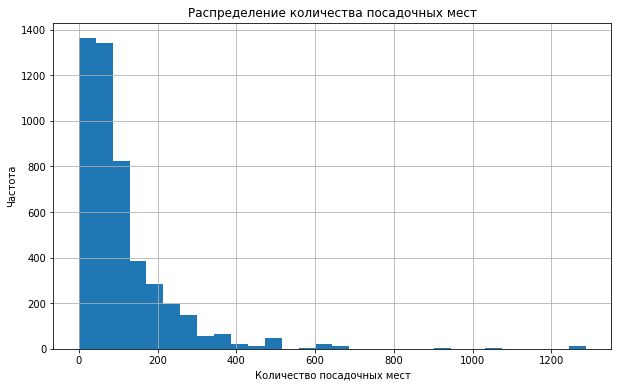

In [58]:
# Строим гистограмму для количества посадочных мест
plt.figure(figsize=(10, 6))
df['seats'].plot(kind='hist', bins=30, title='Распределение количества посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Частота')
plt.grid()
plt.show()

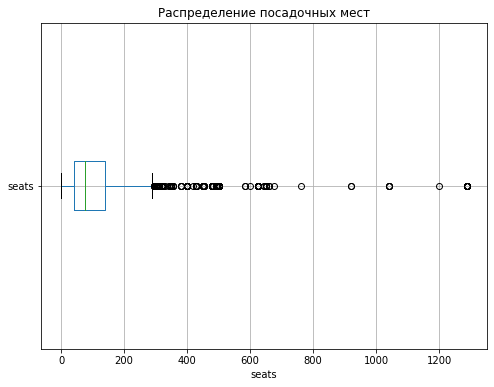

In [59]:
# Построим диаграмму размаха для визуализации распределение посадочных мест в заведениях
boxplot = df.boxplot(column='seats', vert=False, figsize=(8,6))
boxplot.set_title('Распределение посадочных мест')
boxplot.set_xlabel('seats')
plt.show()

In [60]:
# Посмотрим, сколько заведений имеют аномально большое количество мест
df.loc[df['seats'] > 300, ['name', 'category', 'seats']].head(10)

,name,category,seats
127,арарат,кафе,350
171,one_price_coffee,кофейня,350
176,вуди_пицца,пиццерия,350
194,ленкорань,кафе,350
216,грузинский_бульвар,быстрое питание,350
310,vasilchukí_chaihona_№1,ресторан,398
465,бота,пиццерия,398
555,styling_bull_cafe,столовая,310
639,восточная_кухня,кафе,320
676,эскалоп,пиццерия,350


In [61]:
# Медианное количество посадочных мест по категориям
seats_by_category = (
    df
    .groupby('category')['seats']
    .median()
    .sort_values(ascending=False)
)
seats_by_category

category
ресторан           86.0
бар,паб            82.0
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: Float64

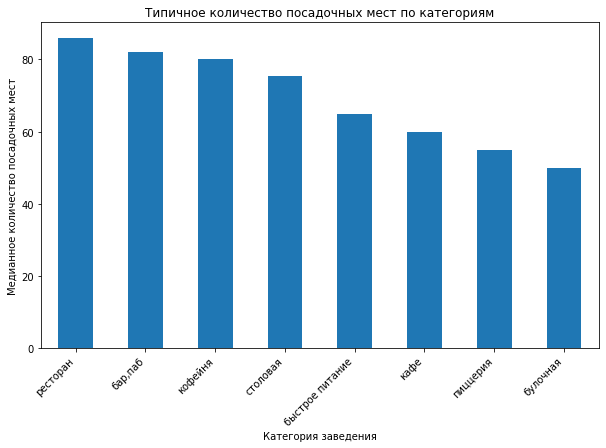

In [62]:
# Медианное количество посадочных мест по категориям
seats_by_category = (
    df
    .groupby('category')['seats']
    .median()
    .sort_values(ascending=False)
)

seats_by_category

#Визуализируем типичное количество мест по категориям
plt.figure(figsize=(10, 6))
seats_by_category.plot(kind='bar')
plt.title('Типичное количество посадочных мест по категориям')
plt.xlabel('Категория заведения')
plt.ylabel('Медианное количество посадочных мест')
plt.xticks(rotation=45, ha='right')
plt.show()

 Наиболее распростаранены заведения общепита с количеством посадочных мест 40 (5 %), 100 посадочных мест (4 %) и 60 мест (3,6 %), наимение популярны с количеством мест 61, 236 мест и 33.
 
 Диаграмма размаха Распределения посадочных мест демонстрирует неравномерное распределние, поскольку "усы" несимметрично расположены.(мы видим правосемитричное распределние, то есть в таком распределении среднее значение больше медианы, и большинство данных сосредоточено в левой части графика. Это означает, что есть несколько высоких значений, которые смещают среднее вправо, но большинство данных всё ещё сосредоточено вокруг более низких значений).
 
Так же имеются выбросы (точки за пределами усов): указывают на заведения с необычно большим количеством посадочных мест по сравнению с остальными. 
*  При анализе заведений с большим количеством посадочных мест (более 300) видно, что такие значения встречаются в разных категориях общественного питания:
Кафе, пиццерии, рестораны, столовые, кофейни и быстрое питание - редкие случаи, вероятно связанные с форматов заведений, оринтированных на большое количество гостей или массовые мероприятия. Аномально большие значения количества посадочных мест являются логичными и объяснимыми, связаны со спецификой форматов заведений и не требуют удаления или корректировки на этапе исследовательского анализа.

Наиболее типичное количество места: в ресторане- 86 , в баре/пабе- 82, в кофейне- 80, в столовой- 75.5, в быст.пит.- 65, в кафе- 60, в пиццерии- 55, в булочной- 50.

---

### Задача 5

Исследуем рейтинг заведений. Визуализируем распределение средних рейтингов по категориям заведений. 

In [63]:
df['rating'].describe()

count    8402.000000
mean        4.230017
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

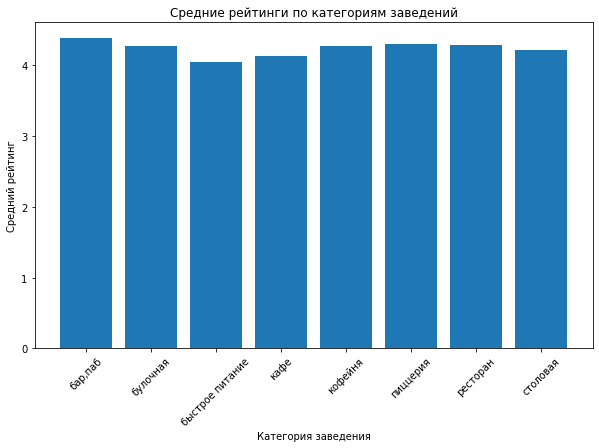

In [64]:
# Группировка заведений по категориям и вычисление среднего рейтинга
average_rating_by_category = df.groupby('category')['rating'].mean().reset_index()

# Построение графика
plt.figure(figsize=(10, 6))
plt.bar(average_rating_by_category['category'], average_rating_by_category['rating'])
plt.title('Средние рейтинги по категориям заведений')
plt.xlabel('Категория заведения')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=45)  # Поворот меток на оси x для лучшего читаемости
plt.show()

Средний рейтинг для разных типов общепитов не сильно отличается. Наибольший средний рейтинг принадлежит барам, пабам, булочным и быстрому питанию. Значит, именно они пользуются наибольшей популярностью у гостей общепита.

In [65]:
# Группировка заведений по категориям и вычисление среднего рейтинга
average_rating_by_category = df.groupby('category')['rating'].mean().reset_index()

print(average_rating_by_category)

          category    rating
0          бар,паб  4.387696
1         булочная  4.268359
2  быстрое питание  4.050249
3             кафе  4.124285
4          кофейня  4.277282
5         пиццерия  4.301264
6         ресторан  4.290402
7         столовая  4.211429


In [66]:
average_rating_by_category.describe()

,rating
count,8.000000
mean,4.238871
std,0.107241
min,4.050249
25%,4.189643
50%,4.272821
75%,4.293117
max,4.387696


Средний рейтинг для разных типов общепитов не сильно отличается. Наибольший средний рейтинг принадлежит барам, пабам, булочным и быстрому питанию. Значит, именно они пользуются наибольшей популярностью у гостей общепита.

---

### Задача 6

Изучим, с какими данными показывают самую сильную корреляцию рейтингов заведений. Построим и визуализируем матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберим самую сильную связь и проверим её.

interval columns not set, guessing: ['rating', 'chain', 'seats', 'middle_avg_bill', 'middle_coffee_cup']


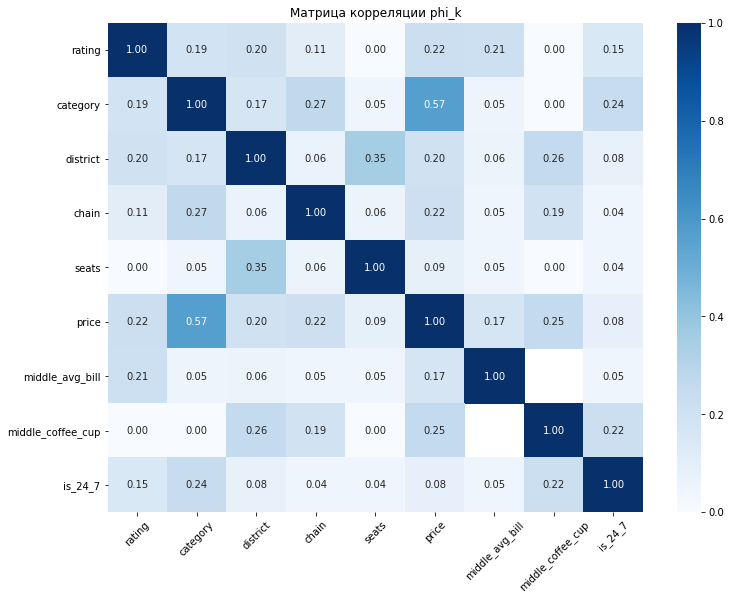

In [67]:
#Формируем датафрейм для корреляционного анализа
corr_data = df[
    [
        'rating',
        'category',
        'district',
        'chain',
        'seats',
        'price',
        'middle_avg_bill',
        'middle_coffee_cup',
        'is_24_7'
    ]]

#Рассчитываем матрицу корреляции phi_k
phik_corr = corr_data.phik_matrix()

#Вывод матрицы
phik_corr

#Визуализируем матрицу корреляции
plt.figure(figsize=(12, 9))
sns.heatmap(
    phik_corr,
    annot=True,
    fmt='.2f',
    cmap='Blues')
plt.title('Матрица корреляции phi_k')
plt.xticks(rotation=45)
plt.show()

In [68]:
rating_by_price = (df.groupby('price')['rating'].mean().sort_values())
rating_by_price

price
низкие           4.173077
средние          4.297874
выше среднего    4.386348
высокие          4.436611
Name: rating, dtype: float64

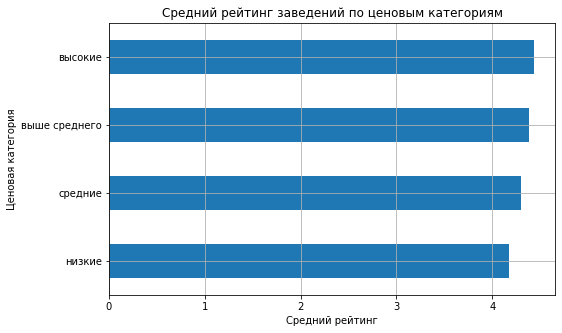

In [69]:
# Визувлизируем связь рейтинга заведения и категорий цен
# Средний рейтинг по ценам
rating_by_price = (df.groupby('price')['rating'].mean().sort_values())

rating_by_price


# Визуализируем зависимость рейтинга от цены
plt.figure(figsize=(8, 5))
rating_by_price.plot(kind='barh')
plt.title('Средний рейтинг заведений по ценовым категориям')
plt.xlabel('Средний рейтинг')
plt.ylabel('Ценовая категория')
plt.grid(True)
plt.show()

Самая сильная связь рейтинга rating наблюдается с категориями цен price (0.22), административным районом district (0.2) и с числом с оценкой среднего чека middle_avg_bill (0.21). Исходя из диаграммы "Средний рейтинг заведений по ценовым категориям", мы наблюдаем, что по мере увеличения среднего рейтинга увеличивается и цена. Хотя в целом разница между показателями среднего рейтинга в зависимости от ценовой категории не сильно разнится.

---

### Задача 7

Сгруппируем данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитаем значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе.

In [70]:
top_15_chains = (df[df['chain'] == 1].
                 groupby(['name', 'category']).
                 agg(count_object=('name', 'count'),
                      mean_rating=('rating', 'mean'))
    .sort_values(by='count_object', ascending=False).head(15).reset_index())

top_15_chains

,name,category,count_object,mean_rating
0,шоколадница,кофейня,119,4.178151
1,домино'с_пицца,пиццерия,76,4.169737
2,додо_пицца,пиццерия,74,4.286486
3,one_price_coffee,кофейня,71,4.064789
4,яндекс_лавка,ресторан,69,3.872464
5,cofix,кофейня,65,4.075385
6,prime,ресторан,49,4.114286
7,кофепорт,кофейня,42,4.147619
8,кулинарная_лавка_братьев_караваевых,кафе,39,4.394872
9,теремок,ресторан,36,4.105556


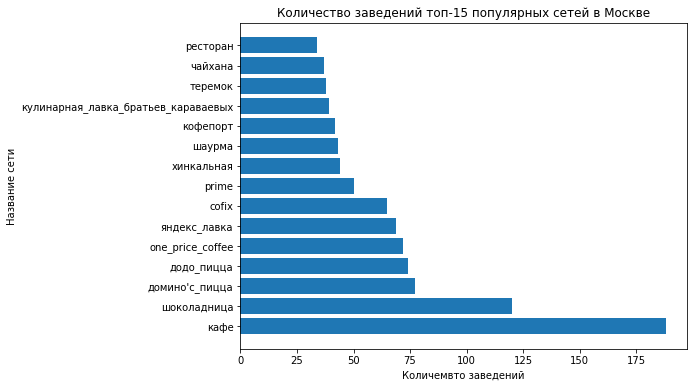

In [71]:
# Группируем данные по названиям заведений и считаем количество заведений каждой сети
chains_grouped = df.groupby('name').size().reset_index(name='count')

# Сортируем по количеству заведений и выбираем топ-15 популярных сетей
top_15_chains = chains_grouped.sort_values(by='count', ascending=False).head(15)

# Находим средние рейтинги для этих сетей
average_ratings = []
for name in top_15_chains['name']:
    average_rating = df[df['name'] == name]['rating'].mean()
    average_ratings.append(average_rating)

top_15_chains['average_rating'] = average_ratings

# Визуализация количества заведений для топ-15 сетей
plt.figure(figsize=(8, 6))
plt.barh(top_15_chains['name'], top_15_chains['count'])
plt.title('Количество заведений топ-15 популярных сетей в Москве')
plt.xlabel('Количемвто заведений')
plt.ylabel('Название сети')
plt.yticks()
plt.show()

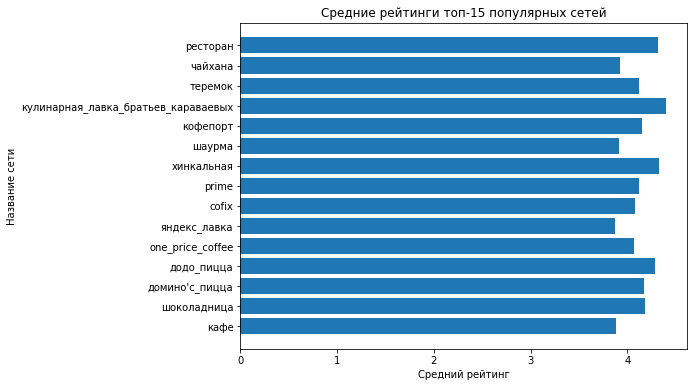

In [72]:
# Визуализация среднего рейтинга для топ-15 сетей
plt.figure(figsize=(8, 6))
plt.barh(top_15_chains['name'], top_15_chains['average_rating'])
plt.title('Средние рейтинги топ-15 популярных сетей')
plt.xlabel('Средний рейтинг')
plt.ylabel('Название сети')
plt.xticks()
plt.show()

По диаграмма видно, что наиболее популярны следующие заведения: "Шоколадница", "Кафе", "Доминос Пицца". Средний рейтин данных заведений составляет ориентировочно 4 балла по 5-балльной шкале.

---

### Задача 8

Изучим вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируем цены в Центральном административном округе и других. Результат сопроводим подходящими визуализациями.

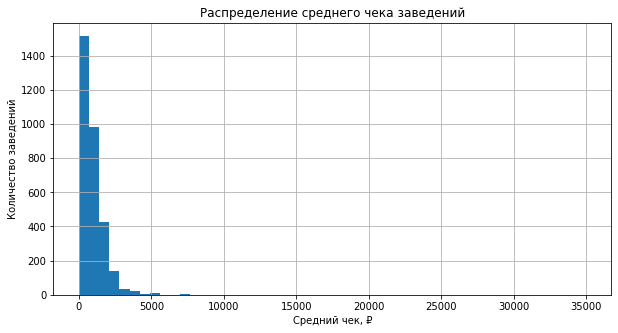

In [73]:
#Визуализируем распределение среднего чека
plt.figure(figsize=(10, 5))
df['middle_avg_bill'].dropna().plot(kind='hist', bins=50)
plt.title('Распределение среднего чека заведений')
plt.xlabel('Средний чек, ₽')
plt.ylabel('Количество заведений')
plt.grid(True)
plt.show()

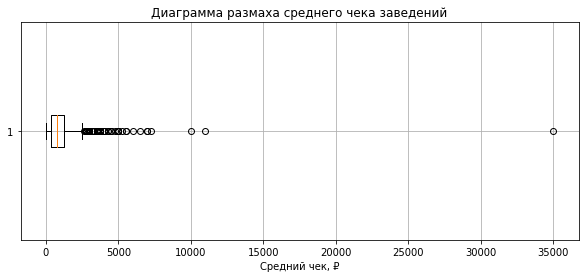

In [74]:
#Построим иаграмму размаха (boxplot) для проверки наличия выбросов
plt.figure(figsize=(10, 4))
plt.boxplot(df['middle_avg_bill'].dropna(), vert=False)
plt.title('Диаграмма размаха среднего чека заведений')
plt.xlabel('Средний чек, ₽')
plt.grid(True)
plt.show()

In [75]:
df['middle_avg_bill'].describe()

count     3149.000000
mean       958.053668
std       1009.732845
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

In [76]:
# Группируем данные по районам и считаем средний чек
grouped_df = df.groupby('district')['middle_avg_bill'].agg(['mean', 'median']).reset_index()

# Переименовываем столбцы для удобства
grouped_df.columns = ['district', 'mean_average_check', 'median_average_check']

# Сортируем данные по среднему чеку
grouped_df = grouped_df.sort_values(by='mean_average_check', ascending=False)

print(grouped_df)

                                  district  mean_average_check  \
5       Центральный административный округ         1191.057547   
1          Западный административный округ         1053.225490   
2          Северный административный округ          927.959627   
8             Южный административный округ          834.398089   
4   Северо-Западный административный округ          822.222930   
0         Восточный административный округ          820.626923   
7      Юго-Западный административный округ          792.561702   
3  Северо-Восточный административный округ          716.611296   
6     Юго-Восточный административный округ          654.097938   

   median_average_check  
5                1000.0  
1                1000.0  
2                 650.0  
8                 500.0  
4                 700.0  
0                 575.0  
7                 600.0  
3                 500.0  
6                 450.0  


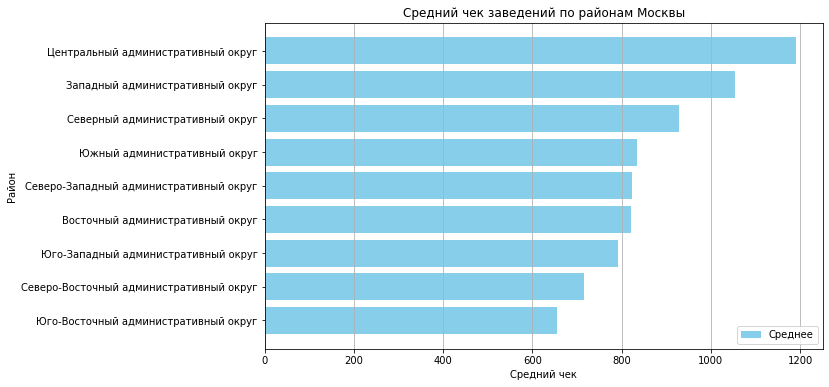

In [77]:
# Группируем данные по районам и считаем средний и медианный чек для каждого района
grouped_df = df.groupby('district')['middle_avg_bill'].agg(['mean', 'median']).reset_index()

# Сортируем районы по среднему чеку 
grouped_df.sort_values(by='mean', inplace=True)

# Создаём горизонтальную гистограмму
plt.figure(figsize=(10, 6))
plt.barh(grouped_df['district'], grouped_df['mean'], color='skyblue', label='Среднее')
plt.title('Средний чек заведений по районам Москвы')
plt.xlabel('Средний чек')
plt.ylabel('Район')
plt.grid(axis='x')
plt.legend()
plt.show()

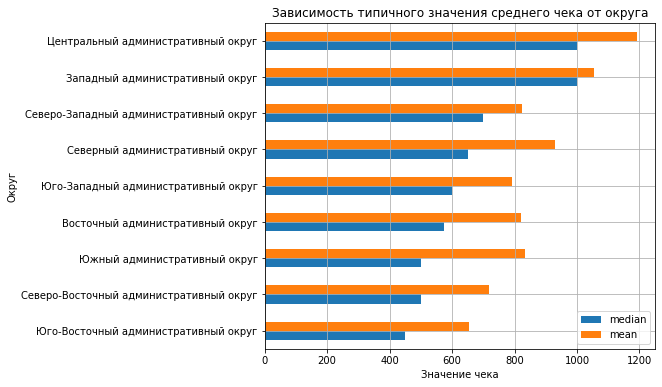

In [78]:
# Комментарий ревьюера 2
grouped = df.groupby('district').agg(median=('middle_avg_bill', 'median'),
                                     mean=('middle_avg_bill', 'mean'))
grouped.sort_values(by='median').plot(kind='barh',
               title=f'Зависимость типичного значения среднего чека от округа',
               legend=True,
               rot=0,
               figsize=(7, 6))
plt.xlabel('Значение чека')
plt.ylabel('Округ')
plt.grid()
plt.show()

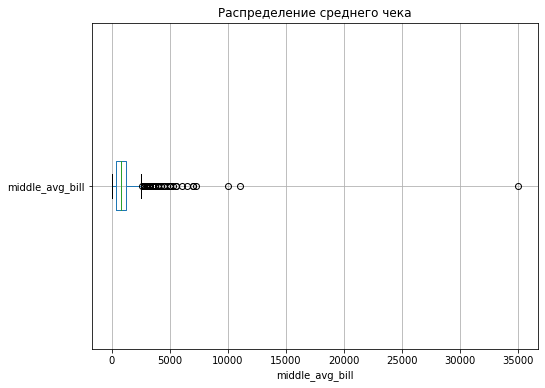

In [79]:
# Построим диаграмму размаха 
boxplot = df.boxplot(column='middle_avg_bill', vert=False, figsize=(8,6))
boxplot.set_title('Распределение среднего чека')
boxplot.set_xlabel('middle_avg_bill')
plt.show()

In [80]:
# Сравнение ЦАО и остальных округов
bill_df = df.loc[df['middle_avg_bill'].notna()].copy()

bill_df.loc[:, 'is_central'] = (
    bill_df['district'] == 'Центральный административный округ'
)

bill_df.groupby('is_central')['middle_avg_bill'].mean()

is_central
False     839.822882
True     1191.057547
Name: middle_avg_bill, dtype: float64

<Figure size 1152x576 with 0 Axes>

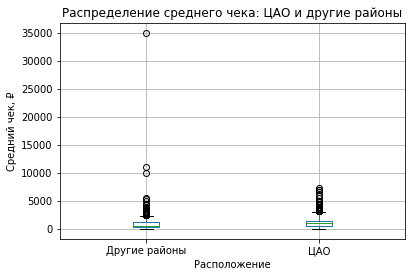

In [81]:
# Визуализирем распределение среднего чека

plt.figure(figsize=(16, 8))
bill_df.boxplot(
    column='middle_avg_bill',
    by='is_central'
)
plt.title('Распределение среднего чека: ЦАО и другие районы')
plt.suptitle('')
plt.xlabel('Расположение')
plt.ylabel('Средний чек, ₽')
plt.xticks([1, 2], ['Другие районы', 'ЦАО'])
plt.show()

Средний чек заведений варьируется от 654 руб. до 1191 руб. Наиболее высокий в Центральном административном округе (1191 руб.), Западном округе (1053 руб.) и Северном округе (927 руб.), а самый дешевый в Северо-Восточном округе (716 руб.) округе и Юго-Восточном округе (654 руб.). Чем дальше заведение от центра города, тем ниже средний чек.

Диаграмма размаха Распределения среднего чека демонстрирует неравномерное распределние, поскольку "усы" несимметрично расположены.(мы видим правосемитричное распределние, то есть в таком распределении среднее значение больше медианы, и большинство данных сосредоточено в левой части графика. Это означает, что есть несколько высоких значений, которые смещают среднее вправо, но большинство данных всё ещё сосредоточено вокруг более низких значений). Так же имеются выбросы (точки за пределами усов): указывают на заведения с необычно большим средним чеком по сравнению с остальными.

Центральный административный округ демонстрирует самый высокий средний чек - около 1191 руб., в остальных округах средний чек заметно ниже - около 840 руб. В Центральном административном округе наблюдаются:
более высокие медианные значения среднего чека; больший разброс цен; наличие заведений с существенно более высоким средним чеком по сравнению с другими районами. 

---

### Промежуточный вывод

Таким образом, мы можем обобщить и оперделить определенные тенденции рынка общепита г. Москвы:

 1.Наибольшая доля в столбце category занимаю: кафе 2327 (25,5 %), рестораны 2043 (25 %) и кофейни 1413 (18%). Наименьшую занимают столовые 315 и булочные 256 (4% и 3%). Доходы москвичей позволяют посещать заведения дорогостоящие и с более высоким уровнем сервиса и кухни. 
 
 2.Наибольшее количество заведений общепита находятся в Центральном административном округе 2242 (28 %), Северном административном округе 900 (11%) и Южном административном округе 891 (10%). Напротив,наименьшее количество наблюдается в Юго-Восточном административном округе 714 (8 %), Северо-Западном административном округе 409 (5 %).В центральном административном округе наибольшей популярностью пользуются рестораны 670 (30%), кафе 464 (21 %), кофейни 428 (19%).Булочные 50 (2%) и столовые 66 (3%) наименее восстребованы. В топе те же группы общепита, что и в статистике по всем районам. Высокая распространенность в Центральном районе обусловлена тем, что там находятся достопримечательности и обитает множество туристов, потенциальных гостей общепита.  

 3.Доля несетевых (57 %) превышает долю сетевых (43%) заведений общепита.Наибольшая доля сетевых заведений приходится на булочные (65%), пиццерии (54%) и кофейни (53%). Потребители общепита предпочитают несетевые заведения с их индивидуальным подходом, нетипичным меню и неоднообразным дизайном помещения.
 
 4.Наиболее распростаранены заведения общепита с количеством посадочных мест 40 (5 %), 100 посадочных мест (4 %) и 60 мест (3,6 %), наимение популярны с количеством мест 61, 236 мест и 33.
Наиболее типичное количество места: в ресторане- 86 , в баре/пабе- 82, в кофейне- 80, в столовой- 75.5, в быст.пит.- 65, в кафе- 60, в пиццерии- 55, в булочной- 50. Распространенность заведений с относительно небольшой площадью посадочных мест говорит о желании людей находится в более приватной и уютной атмосфере.
Так же имеются выбросы (точки за пределами усов): указывают на заведения с необычно большим количеством посадочных мест по сравнению с остальными.
При анализе заведений с большим количеством посадочных мест (более 300) видно, что такие значения встречаются в разных категориях общественного питания: Кафе, пиццерии, рестораны, столовые, кофейни и быстрое питание - редкие случаи, вероятно связанные с форматов заведений, оринтированных на большое количество гостей или массовые мероприятия. Аномально большие значения количества посадочных мест являются логичными и объяснимыми, связаны со спецификой форматов заведений и не требуют удаления или корректировки на этапе исследовательского анализа. Наиболее типичное количество места: в ресторане- 86 , в баре/пабе- 82, в кофейне- 80, в столовой- 75.5, в быст.пит.- 65, в кафе- 60, в пиццерии- 55, в булочной- 50.

 5.Средний рейтинг для разных типов общепитов не сильно отличается. Наибольший средний рейтинг принадлежит барам, пабам, булочным и быстрому питанию. Значит, именно они пользуются наибольшей популярностью у гостей общепита. 

 6.Самая сильная связь рейтинга наблюдается с категориями цен (0.22), административным районом (0.2) и с числом с оценкой среднего чек. Что логично, поскольку среднестатистический человек будет выбирать заведение в соотвествии со своими финасовыми возможностями и территориальным расположение заведения общепита, поскольку г.Москва очень большой. Соотвественно, показатель рейтига сильно связан с этими факторами. 
 Исходя из диаграммы "Средний рейтинг заведений по ценовым категориям", мы наблюдаем, что по мере увеличения среднего рейтинга увеличивается и цена. Хотя в целом разница между показателями среднего рейтинга в зависимости от ценовой категории не сильно разнится.

 7.По диаграмме видно, что наиболее популярны следующие заведения: "Шоколадница", "Кафе", "Доминос Пицца". Средний рейтин данных заведений составляет ориентировочно 4 балла по 5-балльной шкале. 
 
 8.Средний чек заведений варьируется от 654 руб. до 1191 руб. Наиболее высокий в Центральном административном округе (1191 руб.), Западном округе (1053 руб.) и Северном округе (927 руб.), а самый дешевый в Северо-Восточном округе (716 руб.) округе и Юго-Восточном округе (654 руб.). Чем дальше заведение от центра города, тем ниже средний чек.

Диаграмма размаха Распределения среднего чека демонстрирует неравномерное распределние, поскольку "усы" несимметрично расположены.(мы видим правосемитричное распределние, то есть в таком распределении среднее значение больше медианы, и большинство данных сосредоточено в левой части графика. Это означает, что есть несколько высоких значений, которые смещают среднее вправо, но большинство данных всё ещё сосредоточено вокруг более низких значений). Так же имеются выбросы (точки за пределами усов): указывают на заведения с необычно большим средним чеком по сравнению с остальными.

Центральный административный округ демонстрирует самый высокий средний чек - около 1191 руб., в остальных округах средний чек заметно ниже - около 840 руб.). Чем дальше заведение от центра города, тем ниже средний чек. 

## 4. Итоговый вывод и рекомендации


Цель проекта стояла: Провести исследовательский анализ данных заведений общественного питания г. Москвы и выявить места для построения бизнеса в общепите инвесторами. Задачами проекта яалялись: загрузка данных и знакомство с ними, предобработка данных, исследовательский анализ данных и предоставление итоговых выводов.


В результате предобработки данных были выполнены следующие действия:
Изучены пропуски в данных. В датафрейме df обнаружено 536 пропусков в столбце hours — это 6% данных, в столбце seats 3611 пропусков, это 43 %, в столбце price 5091 (61%), в стобце avg_bill 4590 (55%), в стобце middle_avg_bill 5257 (63 %) в стобце middle_coffee_cup 7871 (94 %). Так же произвели нормализацию данных в столбцах name и address. Данные проверили на явные и неявные дубликаты — их нет.

В исследовательской части проекта были определены следующие тенденции рынка общепита:
* 1.Наибольшая доля в столбце category занимаю: кафе 2327 (25,5 %), рестораны 2043 (25 %) и кофейни 1413 (18%). Наименьшую занимают столовые 315 и булочные 256 (4% и 3%). Доходы москвичей позволяют посещать заведения дорогостоящие и с более высоким уровнем сервиса и кухни.
* 2.Наибольшее количество заведений общепита находятся в Центральном административном округе 2242 (28 %), Северном административном округе 900 (11%) и Южном административном округе 891 (10%). Напротив,наименьшее количество наблюдается в Юго-Восточном административном округе 714 (8 %), Северо-Западном административном округе 409 (5 %).В центральном административном округе наибольшей популярностью пользуются рестораны 670 (30%), кафе 464 (21 %), кофейни 428 (19%).Булочные 50 (2%) и столовые 66 (3%) наименее восстребованы. В топе те же группы общепита, что и в статистике по всем районам. Высокая распространенность в Центральном районе обусловлена тем, что там находятся достопримечательности и обитает множество туристов, потенциальных гостей общепита.
* 3.Доля несетевых (57 %) превышает долю сетевых (43%) заведений общепита.Наибольшая доля сетевых заведений приходится на булочные (65%), пиццерии (54%) и кофейни (53%). Потребители общепита предпочитают несетевые заведения с их индивидуальным подходом, нетипичным меню и неоднообразным дизайном помещения.
* 4.Наиболее распростаранены заведения общепита с количеством посадочных мест 40 (5 %), 100 посадочных мест (4 %) и 60 мест (3,6 %), наимение популярны с количеством мест 61, 236 мест и 33.Распространенность заведений с относительно небольшой площадью посадочных мест говорит о желании людей находится в более приватной и уютной атмосфере.
* 5.Самая сильная связь рейтинга rating наблюдается с категориями цен price (0.22), административным районом district (0.2) и с числом с оценкой среднего чека middle_avg_bill (0.21). Исходя из диаграммы "Средний рейтинг заведений по ценовым категориям", мы наблюдаем, что по мере увеличения среднего рейтинга увеличивается и цена. Хотя в целом разница между показателями среднего рейтинга в зависимости от ценовой категории не сильно разнится.
* 7.По диаграмме видно, что наиболее популярны следующие заведения: "Шоколадница", "Кафе", "Доминос Пицца". Средний рейтин данных заведений составляет ориентировочно 4 балла по 5-балльной шкале.
* 8.Средний чек заведений варьируется от 654 руб. до 1191 руб. Наиболее высокий в Центральном административном округе (1191 руб.), Западном округе (1053 руб.) и Северном округе (927 руб.), а самый дешевый в Северо-Восточном округе (716 руб.) округе и Юго-Восточном округе (654 руб.).Чем дальше заведение от центра города,тем ниже средний чек.

Таким образом, используя полученные выводы, мы получили аналитическое представление о заведениях рынка общепита и можем дать некоторые рекомендации инвесторам.
Благоприятным является вариант открытия ресторанов, кофейн, либо кафе. Самый удачный вариант - инвестировать в открытие ресторана или кафе со средней посадкой в Центральном административной округе, если позволяют финансы с уровнем аренды помещения. Кухня должна быть нетипичной, меню разнообразным, интерьер современный и интересный, высокий уровень спроса и клиентоарентированность, с сохранение среднего уровня чека в данном районе.